<a href="https://colab.research.google.com/github/pandeyp84/Deep-Learning-Tutorials/blob/main/Transfer_learning_vs_finetuning_5th_April_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Transfer Learning vs Fine-Tuning
## A Complete, Visual, Code-First Lecture Notebook

---

> **The central question this notebook answers:**  
> *You have a pretrained ResNet. You have fruit class images. What do you actually DO?*

---


---
## Section 1 — Setup

We use **ResNet-18** pretrained on ImageNet (1.2M images, 1000 classes).  
Our target task: classify **4 fruit class** from a small dataset.

In [ ]:
# ── Core imports ──────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.models as models
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from copy import deepcopy
import time, warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print()
print("Our scenario:")
print("  Source domain : ImageNet (1.2M images, 1000 classes) ← already trained")
print("  Target domain : Dog breeds (small dataset, 10 classes) ← what we want")
print("  Pretrained    : ResNet-18")

Device : cpu
PyTorch: 2.10.0+cpu

Our scenario:
  Source domain : ImageNet (1.2M images, 1000 classes) ← already trained
  Target domain : Dog breeds (small dataset, 10 classes) ← what we want
  Pretrained    : ResNet-18


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split

# Transform (VERY IMPORTANT)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Dataset
dataset = datasets.ImageFolder(
    root="/content/drive/MyDrive/e_Master/fruit_classification",
    transform=transform
)

# Class mapping
print(dataset.class_to_idx)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(test_dataset,batch_size=32)
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
# Test
for images, labels in train_loader:
    print(images.shape)  # (32, 3, 224, 224)
    print(labels.shape)  # (32,)
    break

{'apple fruit': 0, 'banana fruit': 1, 'cherry fruit': 2, 'chickoo fruit': 3, 'grapes fruit': 4, 'kiwi fruit': 5, 'mango fruit': 6, 'orange fruit': 7, 'strawberry fruit': 8}
Train size: 287
Test size: 72
torch.Size([32, 3, 224, 224])
torch.Size([32])


In [ ]:
print(len(dataset.classes))
NUM_CLASSES = len(dataset.classes)

9


---
## Section 2 — What is a Pretrained Model? 🔬

### The Core Insight

When ResNet-18 was trained on ImageNet for 90 epochs, it learned a **feature hierarchy**:

```
Early layers   →  edges, corners, colour blobs      (universal, transferable!)
Middle layers  →  textures, parts, patterns          (somewhat transferable)
Late layers    →  object parts, high-level concepts  (task-specific, may need updating)
Final layer    →  1000 ImageNet class scores         (ALWAYS replaced)
```

**Key insight:** Dog fur, dog ears, dog eyes — these features were already learned on ImageNet (it has 120 dog breeds!). We don't need to relearn them. We just need to **redirect** those features toward our specific 10 breeds.

In [ ]:
# ── Load ResNet-18 pretrained on ImageNet ─────────────────────────────────────
base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

print("ResNet-18 Architecture — Layer Groups:")
print("=" * 65)

layer_groups = {
    'conv1 (stem)':   [base_model.conv1, base_model.bn1],
    'layer1 (early)': list(base_model.layer1.children()),
    'layer2 (early-mid)': list(base_model.layer2.children()),
    'layer3 (mid-late)':  list(base_model.layer3.children()),
    'layer4 (late)':  list(base_model.layer4.children()),
    'fc (head)':      [base_model.fc],
}

total = 0
for name, layers in layer_groups.items():
    params = sum(p.numel() for layer in layers for p in layer.parameters())
    total += params
    level = '(abstract/task-specific)' if 'late' in name or 'head' in name else  '(task-specific → REPLACE)' if 'head' in name else \
            '(universal → safe to freeze)'
    if 'head' in name:
        level = '← ALWAYS REPLACED'
    elif 'early' in name or 'stem' in name:
        level = '← universal features (edges, colours)'
    elif 'mid' in name:
        level = '← texture, pattern features'
    else:
        level = '← high-level, task-specific'
    print(f"  {name:<22} {params:>8,} params  {level}")

print("-" * 65)
print(f"  {'TOTAL':<22} {total:>8,} params")
print()
print(f"  Original output: 1000 classes (ImageNet)")
print(f"  Our target:       {NUM_CLASSES} classes (dog breeds)")
print(f"  What we MUST change: the final fc layer")

ResNet-18 Architecture — Layer Groups:
  conv1 (stem)              9,536 params  ← universal features (edges, colours)
  layer1 (early)          147,968 params  ← universal features (edges, colours)
  layer2 (early-mid)      525,568 params  ← universal features (edges, colours)
  layer3 (mid-late)      2,099,712 params  ← texture, pattern features
  layer4 (late)          8,393,728 params  ← high-level, task-specific
  fc (head)               513,000 params  ← ALWAYS REPLACED
-----------------------------------------------------------------
  TOTAL                  11,689,512 params

  Original output: 1000 classes (ImageNet)
  Our target:       9 classes (dog breeds)
  What we MUST change: the final fc layer


---
## Section 3 — Transfer Learning (Feature Extraction) 🧊

### The Idea: Freeze the backbone, train only the head

```
Pretrained ResNet-18
┌─────────────────────────────────────────────┐
│  conv1 → layer1 → layer2 → layer3 → layer4  │  ← FROZEN (weights locked 🧊)
│            These are our fixed "feature extractor"            │
└─────────────────────────────────────────────┘
               ↓  512-dim feature vector
        ┌──────────────┐
        │  New FC head  │  ← TRAINED from scratch
        │  512 → 10    │
        └──────────────┘
```

**Analogy:** You hire an expert photographer (ImageNet-trained backbone). You don't retrain them on how to hold a camera. You just tell them: "Point it at dog breeds and I'll put a new label on the photos."

**When to use:**
- Very small dataset (< 1000 images per class)
- Target domain is similar to source domain
- Limited compute/time
- Risk of overfitting is high

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TRANSFER LEARNING — Step by Step
# ─────────────────────────────────────────────────────────────────────────────

def build_transfer_learning_model(num_classes=10, freeze_backbone=True):
    """Build a transfer learning model: frozen backbone + new trainable head."""

    # Step 1: Load pretrained backbone
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Step 2: FREEZE all backbone parameters
    if freeze_backbone:
        for name, param in model.named_parameters():
            param.requires_grad = False  # ← This is how you freeze in PyTorch
        print("🧊 Backbone FROZEN — all ResNet layers locked")

    # Step 3: REPLACE the head with a new one for our task
    # Original: model.fc = Linear(512, 1000)  ← ImageNet
    # New:      model.fc = Linear(512, 10)    ← our dog breeds
    in_features = model.fc.in_features  # = 512 for ResNet-18
    model.fc = nn.Linear(in_features, num_classes)  # New head — trainable by default

    print(f"🔄 Head REPLACED: Linear({in_features}, 1000) → Linear({in_features}, {num_classes})")
    return model


tl_model = build_transfer_learning_model(num_classes=NUM_CLASSES)
tl_model = tl_model.to(DEVICE)

# ── Count parameters ─────────────────────────────────────────────────────────
total_params    = sum(p.numel() for p in tl_model.parameters())
trainable_params= sum(p.numel() for p in tl_model.parameters() if p.requires_grad)
frozen_params   = total_params - trainable_params

print()
print("Parameter Summary:")
print(f"  Total params     : {total_params:>10,}")
print(f"  Frozen params    : {frozen_params:>10,}  ({100*frozen_params/total_params:.1f}%) ← not updated")
print(f"  Trainable params : {trainable_params:>10,}  ({100*trainable_params/total_params:.1f}%) ← only these learn")
print()
print("Trainable layers:")
for name, param in tl_model.named_parameters():
    if param.requires_grad:
        print(f"  ✅ {name:<30} {param.numel():>8,} params")

🧊 Backbone FROZEN — all ResNet layers locked
🔄 Head REPLACED: Linear(512, 1000) → Linear(512, 9)

Parameter Summary:
  Total params     : 11,181,129
  Frozen params    : 11,176,512  (100.0%) ← not updated
  Trainable params :      4,617  (0.0%) ← only these learn

Trainable layers:
  ✅ fc.weight                         4,608 params
  ✅ fc.bias                               9 params


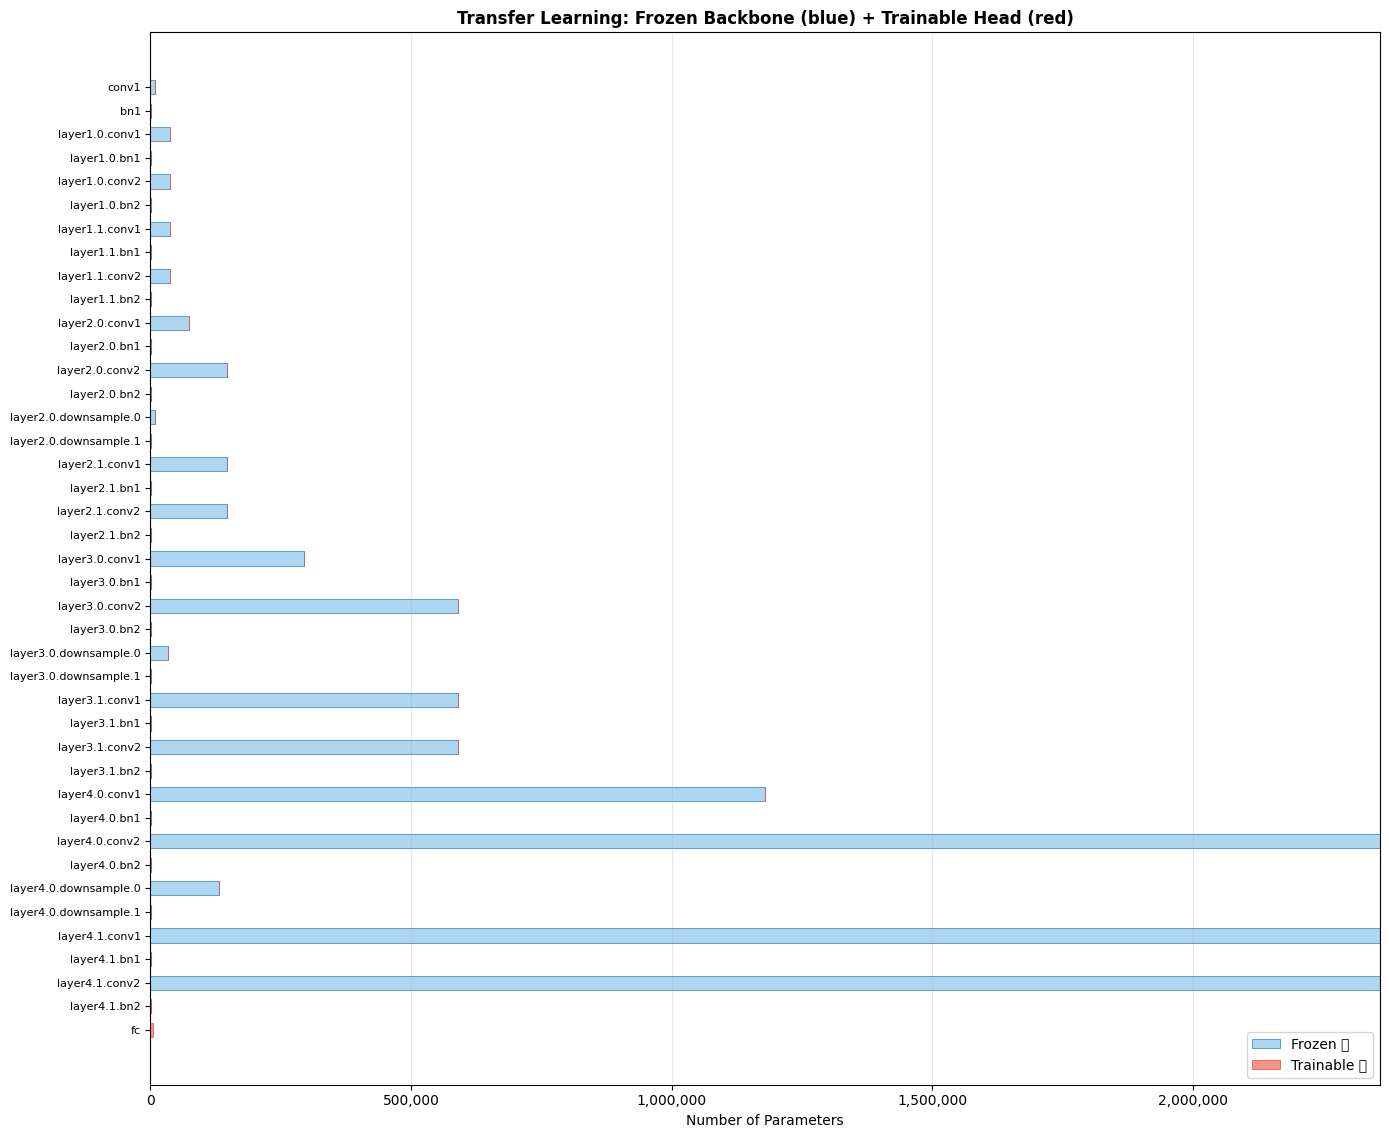

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALISE: Frozen vs Trainable layers
# ─────────────────────────────────────────────────────────────────────────────

def plot_parameter_status(model, title='Model Parameter Status'):
    layer_names, frozen_list, trainable_list = [], [], []

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear, nn.BatchNorm2d)):
            p_all   = sum(p.numel() for p in module.parameters())
            p_train = sum(p.numel() for p in module.parameters() if p.requires_grad)
            if p_all > 0:
                layer_names.append(name if len(name) < 22 else '...' + name[-18:])
                frozen_list.append(p_all - p_train)
                trainable_list.append(p_train)

    fig, ax = plt.subplots(figsize=(14, max(4, len(layer_names) * 0.28)))
    y = np.arange(len(layer_names))
    h = 0.6

    bars_f = ax.barh(y, frozen_list, h, label='Frozen 🧊', color='#AED6F1', edgecolor='#2980B9', linewidth=0.5)
    bars_t = ax.barh(y, trainable_list, h, left=frozen_list,
                      label='Trainable 🔥', color='#F1948A', edgecolor='#E74C3C', linewidth=0.5)

    ax.set_yticks(y)
    ax.set_yticklabels(layer_names, fontsize=8)
    ax.set_xlabel('Number of Parameters')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.legend(fontsize=10, loc='lower right')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_parameter_status(tl_model, 'Transfer Learning: Frozen Backbone (blue) + Trainable Head (red)')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN: Transfer Learning model
# ─────────────────────────────────────────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct    += (out.argmax(1) == y).sum().item()
        total      += X.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)
            total_loss += loss.item() * X.size(0)
            correct    += (out.argmax(1) == y).sum().item()
            total      += X.size(0)
    return total_loss / total, correct / total

def train_model(model, train_loader, val_loader, lr, epochs, device, label=''):
    """Train model and record history."""
    # Only optimise trainable parameters!
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    t0 = time.time()
    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"  [{label}] Epoch {epoch+1:>2}/{epochs} | "
                  f"Train loss: {tr_loss:.4f} acc: {tr_acc:.3f} | "
                  f"Val loss: {vl_loss:.4f} acc: {vl_acc:.3f}")

    elapsed = time.time() - t0
    print(f"  Training time: {elapsed:.1f}s")
    return history


EPOCHS = 8
TL_LR  = 1e-3   # Higher LR is OK — only training the small head

print("Training: Transfer Learning (head only)")
print(f"  LR: {TL_LR} | Epochs: {EPOCHS}")
print()
tl_history = train_model(tl_model, train_loader, val_loader,
                          lr=TL_LR, epochs=EPOCHS, device=DEVICE, label='TL')

Training: Transfer Learning (head only)
  LR: 0.001 | Epochs: 8

  [TL] Epoch  1/8 | Train loss: 2.1032 acc: 0.237 | Val loss: 1.7521 acc: 0.458
  [TL] Epoch  2/8 | Train loss: 1.5314 acc: 0.613 | Val loss: 1.2815 acc: 0.708
  [TL] Epoch  4/8 | Train loss: 0.9212 acc: 0.854 | Val loss: 0.8164 acc: 0.833
  [TL] Epoch  6/8 | Train loss: 0.5880 acc: 0.913 | Val loss: 0.6132 acc: 0.806
  [TL] Epoch  8/8 | Train loss: 0.4634 acc: 0.944 | Val loss: 0.5213 acc: 0.861
  Training time: 581.9s


---
## 🟨 Assignment 1 — Try Different Head Architectures

**Time: 12 minutes (individual)**

The head is the only part that trains in transfer learning — so its design matters.

### Tasks:
1. **Simple head** (current): `Linear(512, 10)` — 1 layer
2. **Deep head**: `Linear(512, 256) → ReLU → Dropout → Linear(256, 10)` — 2 layers
3. **Bottleneck head**: `Linear(512, 64) → ReLU → Linear(64, 10)` — compressed

### Questions:
1. Which head gives better validation accuracy? Why?
2. A deeper head has more capacity — does that always help with small data?
3. What is the risk of a very complex head on a small dataset?

---
## Section 5 — Fine-Tuning 🔥

### The Idea: Unfreeze layers and let them adapt

```
Pretrained ResNet-18
┌──────────────────┐
│  conv1, layer1   │  ← Stay FROZEN  (universal features — don't touch)
├──────────────────┤
│  layer2, layer3  │  ← UNFROZEN 🔥 (adapt to  textures)
├──────────────────┤
│  layer4          │  ← UNFROZEN 🔥 (adapt to specific concepts)
├──────────────────┤
│  New FC head     │  ← UNFROZEN 🔥 (our new classifier)
└──────────────────┘
```

**Critical difference from Transfer Learning:**
- Transfer Learning: backbone is a **fixed feature extractor** — weights never change
- Fine-Tuning: backbone weights **DO change** — they adjust to the new task

**The danger:** If you unfreeze all layers with a large learning rate, you destroy the pretrained weights (**catastrophic forgetting**).

**The solution:** Use a very small learning rate — typically 10–100× smaller than training from scratch.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FINE-TUNING — Step by Step
# ─────────────────────────────────────────────────────────────────────────────

def build_finetune_model(num_classes=10, unfreeze_from='layer3'):
    """
    Build a fine-tuning model.

    Strategy: freeze early layers, unfreeze from 'unfreeze_from' onwards.
    Common choices: 'layer2', 'layer3', 'layer4', or 'all'
    """
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Step 1: Start by freezing EVERYTHING
    for param in model.parameters():
        param.requires_grad = False

    # Step 2: Selectively unfreeze from the chosen layer onwards
    layer_order = ['conv1', 'bn1', 'layer1', 'layer2', 'layer3', 'layer4', 'fc']
    unfreezing = False

    if unfreeze_from == 'all':
        for param in model.parameters():
            param.requires_grad = True
    else:
        for layer_name in layer_order:
            if layer_name == unfreeze_from:
                unfreezing = True
            if unfreezing:
                layer = getattr(model, layer_name)
                for param in layer.parameters():
                    param.requires_grad = True

    # Step 3: Replace head (always)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    # fc head is always trainable (newly created)
    for param in model.fc.parameters():
        param.requires_grad = True

    return model.to(DEVICE)


# Build fine-tuning model: unfreeze from layer3 onwards
ft_model = build_finetune_model(num_classes=NUM_CLASSES, unfreeze_from='layer3')

total_p    = sum(p.numel() for p in ft_model.parameters())
trainable_p= sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
frozen_p   = total_p - trainable_p

print("Fine-Tuning Model (unfreeze from layer3):")
print(f"  Total params     : {total_p:>10,}")
print(f"  Frozen params    : {frozen_p:>10,}  ({100*frozen_p/total_p:.1f}%)")
print(f"  Trainable params : {trainable_p:>10,}  ({100*trainable_p/total_p:.1f}%)")
print()
print("Layer status:")
for name, module in ft_model.named_children():
    params = list(module.parameters())
    if params:
        trainable = any(p.requires_grad for p in params)
        status = '🔥 TRAINABLE' if trainable else '🧊 FROZEN'
        n = sum(p.numel() for p in params)
        print(f"  {name:<12} {status}  ({n:,} params)")

Fine-Tuning Model (unfreeze from layer3):
  Total params     : 11,181,129
  Frozen params    :    683,072  (6.1%)
  Trainable params : 10,498,057  (93.9%)

Layer status:
  conv1        🧊 FROZEN  (9,408 params)
  bn1          🧊 FROZEN  (128 params)
  layer1       🧊 FROZEN  (147,968 params)
  layer2       🧊 FROZEN  (525,568 params)
  layer3       🔥 TRAINABLE  (2,099,712 params)
  layer4       🔥 TRAINABLE  (8,393,728 params)
  fc           🔥 TRAINABLE  (4,617 params)


In [ ]:
# ── Differential learning rates — key fine-tuning technique ─────────────────
# Different parts of the network should have different learning rates:
#   Backbone (unfrozen): very small LR — gentle nudge
#   Head (new):          larger LR — learn quickly

def make_differential_optimizer(model, head_lr=1e-3, backbone_lr=1e-5):
    """
    Create optimizer with different learning rates for backbone vs head.
    This is a best practice for fine-tuning.
    """
    head_params     = list(model.fc.parameters())
    backbone_params = [p for name, p in model.named_parameters()
                       if p.requires_grad and not name.startswith('fc')]

    return optim.Adam([
        {'params': backbone_params, 'lr': backbone_lr},   # gentle
        {'params': head_params,     'lr': head_lr},        # faster
    ])

print("Differential Learning Rate Setup:")
print(f"  Backbone LR : 1e-5  (very gentle — don't destroy pretrained knowledge)")
print(f"  Head LR     : 1e-3  (normal — learning from scratch)")
print(f"  Ratio       : 100×  (head trains 100× faster than backbone)")
print()
print("Why? The backbone already has good features.")
print("     A large LR would overwrite them (catastrophic forgetting).")
print("     A tiny LR lets them gently adapt to the new domain.")

# Train fine-tuning model
FT_HEAD_LR     = 1e-3
FT_BACKBONE_LR = 1e-5

optimizer_ft = make_differential_optimizer(ft_model, FT_HEAD_LR, FT_BACKBONE_LR)
criterion    = nn.CrossEntropyLoss()

print()
print("Training: Fine-Tuning (layer3 + layer4 + head unfrozen)")
print(f"  Head LR: {FT_HEAD_LR} | Backbone LR: {FT_BACKBONE_LR} | Epochs: {EPOCHS}")
print()

ft_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
t0 = time.time()
for epoch in range(EPOCHS):
    trl, tra = train_one_epoch(ft_model, train_loader, optimizer_ft, criterion, DEVICE)
    vll, vla = evaluate(ft_model, val_loader, criterion, DEVICE)
    ft_history['train_loss'].append(trl)
    ft_history['val_loss'].append(vll)
    ft_history['train_acc'].append(tra)
    ft_history['val_acc'].append(vla)
    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(f"  [FT] Epoch {epoch+1:>2}/{EPOCHS} | "
              f"Train loss: {trl:.4f} acc: {tra:.3f} | "
              f"Val loss: {vll:.4f} acc: {vla:.3f}")
print(f"  Training time: {time.time()-t0:.1f}s")

Differential Learning Rate Setup:
  Backbone LR : 1e-5  (very gentle — don't destroy pretrained knowledge)
  Head LR     : 1e-3  (normal — learning from scratch)
  Ratio       : 100×  (head trains 100× faster than backbone)

Why? The backbone already has good features.
     A large LR would overwrite them (catastrophic forgetting).
     A tiny LR lets them gently adapt to the new domain.

Training: Fine-Tuning (layer3 + layer4 + head unfrozen)
  Head LR: 0.001 | Backbone LR: 1e-05 | Epochs: 8

  [FT] Epoch  1/8 | Train loss: 2.1064 acc: 0.254 | Val loss: 1.7751 acc: 0.472
  [FT] Epoch  2/8 | Train loss: 1.2978 acc: 0.756 | Val loss: 1.0888 acc: 0.792
  [FT] Epoch  4/8 | Train loss: 0.5494 acc: 0.934 | Val loss: 0.5888 acc: 0.833
  [FT] Epoch  6/8 | Train loss: 0.2960 acc: 0.965 | Val loss: 0.4551 acc: 0.847
  [FT] Epoch  8/8 | Train loss: 0.1912 acc: 0.983 | Val loss: 0.3738 acc: 0.903
  Training time: 666.2s


---
## 🟨 Assignment 2 — Experiment with Layer Unfreezing

**Time: 12 minutes (pair work)**

The choice of *how much to unfreeze* is a key fine-tuning hyperparameter.

### Tasks:
Run the four experiments below. Each unfreezes a different amount.

| Experiment | What's unfrozen | Expected behaviour |
|-----------|----------------|-------------------|
| A | Head only | = Transfer Learning |
| B | layer4 + head | Conservative fine-tuning |
| C | layer3 + layer4 + head | Moderate fine-tuning |
| D | All layers | Aggressive fine-tuning |

### Questions:
1. As you unfreeze more, does val accuracy always improve?
2. Which strategy risks overfitting most with our 400-image dataset?
3. What would change if we had 10,000 images?

---
## Section 7 — Key Differences: A Complete Comparison 📊

| Aspect | Transfer Learning | Fine-Tuning |
|--------|-----------------|-------------|
| **Backbone weights change?** | ❌ No (frozen) | ✅ Yes (updated) |
| **Parameters trained** | Head only (~0.5%) | Head + part of backbone |
| **Dataset size needed** | Small (100–1000) | Medium-large (1000+) |
| **Risk of overfitting** | Low | Higher |
| **Risk of catastrophic forgetting** | None | Yes, if LR too high |
| **Training speed** | Very fast | Slower |
| **Peak accuracy potential** | Good | Better |
| **Typical LR** | 1e-3 | 1e-5 (backbone), 1e-3 (head) |
| **Domains must be similar?** | Helpful but not essential | More important |

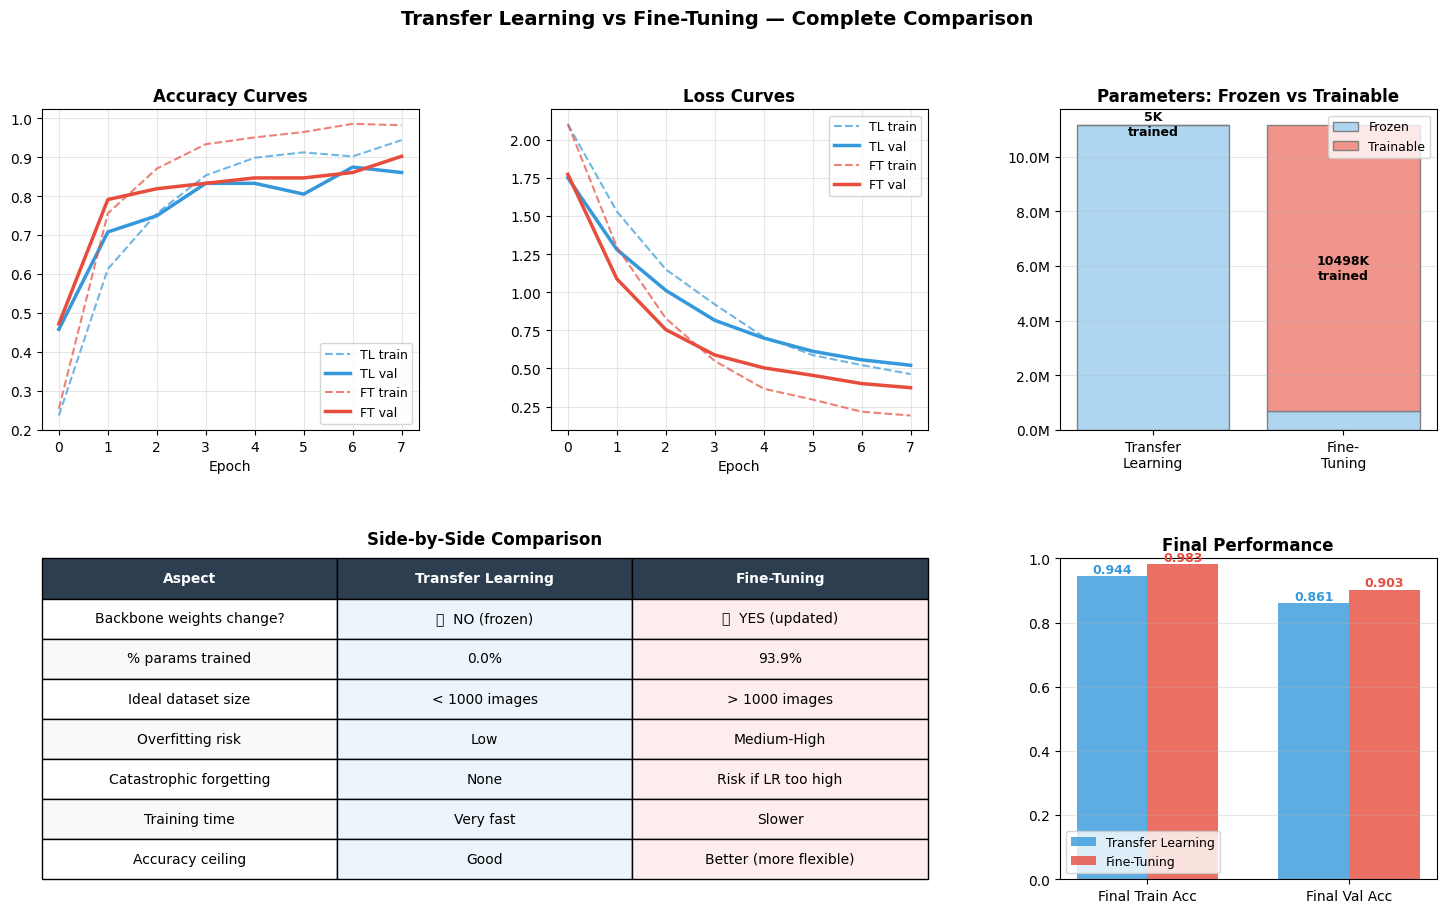

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# HEAD-TO-HEAD COMPARISON: TL vs Fine-Tuning on the same task
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('Transfer Learning vs Fine-Tuning — Complete Comparison', fontsize=14, fontweight='bold')

TL_COLOR = '#3498DB'
FT_COLOR = '#E74C3C'

# Panel 1: Training curves — accuracy
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(tl_history['train_acc'], '--', color=TL_COLOR, alpha=0.7, label='TL train')
ax1.plot(tl_history['val_acc'],   '-',  color=TL_COLOR, lw=2.5, label='TL val')
ax1.plot(ft_history['train_acc'], '--', color=FT_COLOR, alpha=0.7, label='FT train')
ax1.plot(ft_history['val_acc'],   '-',  color=FT_COLOR, lw=2.5, label='FT val')
ax1.set_title('Accuracy Curves', fontweight='bold'); ax1.set_xlabel('Epoch')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# Panel 2: Training curves — loss
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(tl_history['train_loss'], '--', color=TL_COLOR, alpha=0.7, label='TL train')
ax2.plot(tl_history['val_loss'],   '-',  color=TL_COLOR, lw=2.5, label='TL val')
ax2.plot(ft_history['train_loss'], '--', color=FT_COLOR, alpha=0.7, label='FT train')
ax2.plot(ft_history['val_loss'],   '-',  color=FT_COLOR, lw=2.5, label='FT val')
ax2.set_title('Loss Curves', fontweight='bold'); ax2.set_xlabel('Epoch')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# Panel 3: Parameter efficiency bar chart
ax3 = fig.add_subplot(gs[0, 2])
tl_tp = sum(p.numel() for p in tl_model.parameters() if p.requires_grad)
ft_tp = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in tl_model.parameters())
categories = ['Transfer\nLearning', 'Fine-\nTuning']
trainable  = [tl_tp, ft_tp]
frozen_    = [total - tl_tp, total - ft_tp]

bars1 = ax3.bar(categories, frozen_,   color='#AED6F1', label='Frozen',    edgecolor='gray')
bars2 = ax3.bar(categories, trainable, color='#F1948A', label='Trainable', edgecolor='gray',
                bottom=frozen_)
ax3.set_title('Parameters: Frozen vs Trainable', fontweight='bold')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax3.legend(fontsize=9); ax3.grid(axis='y', alpha=0.3)
for bar, tp in zip([bars2[0], bars2[1]], trainable):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
             f'{tp/1e3:.0f}K\ntrained', ha='center', va='center', fontsize=9, fontweight='bold')

# Panel 4: Concept comparison table
ax4 = fig.add_subplot(gs[1, 0:2])
ax4.axis('off')
table_data = [
    ['Backbone weights change?', '❌  NO (frozen)', '✅  YES (updated)'],
    ['% params trained',
     f'{100*tl_tp/total:.1f}%', f'{100*ft_tp/total:.1f}%'],
    ['Ideal dataset size', '< 1000 images', '> 1000 images'],
    ['Overfitting risk', 'Low', 'Medium-High'],
    ['Catastrophic forgetting', 'None', 'Risk if LR too high'],
    ['Training time', 'Very fast', 'Slower'],
    ['Accuracy ceiling', 'Good', 'Better (more flexible)'],
]
col_labels = ['Aspect', 'Transfer Learning', 'Fine-Tuning']
table = ax4.table(cellText=table_data, colLabels=col_labels,
                   cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False); table.set_fontsize(10)
for j in range(3):
    table[0, j].set_facecolor('#2C3E50'); table[0, j].set_text_props(color='white', weight='bold')
for i in range(1, len(table_data)+1):
    table[i, 1].set_facecolor('#EBF5FB')
    table[i, 2].set_facecolor('#FDEDEC')
    if i % 2 == 0:
        table[i, 0].set_facecolor('#F8F9FA')
ax4.set_title('Side-by-Side Comparison', fontweight='bold', pad=10)

# Panel 5: Final metrics
ax5 = fig.add_subplot(gs[1, 2])
metrics = ['Final Train Acc', 'Final Val Acc']
tl_vals = [tl_history['train_acc'][-1], tl_history['val_acc'][-1]]
ft_vals = [ft_history['train_acc'][-1], ft_history['val_acc'][-1]]
x = np.arange(len(metrics)); w = 0.35
ax5.bar(x - w/2, tl_vals, w, label='Transfer Learning', color=TL_COLOR, alpha=0.8)
ax5.bar(x + w/2, ft_vals, w, label='Fine-Tuning',        color=FT_COLOR, alpha=0.8)
ax5.set_xticks(x); ax5.set_xticklabels(metrics); ax5.set_ylim(0, 1)
ax5.set_title('Final Performance', fontweight='bold')
ax5.legend(fontsize=9); ax5.grid(axis='y', alpha=0.3)
for i, (tv, fv) in enumerate(zip(tl_vals, ft_vals)):
    ax5.text(i - w/2, tv + 0.01, f'{tv:.3f}', ha='center', fontsize=9, color=TL_COLOR, fontweight='bold')
    ax5.text(i + w/2, fv + 0.01, f'{fv:.3f}', ha='center', fontsize=9, color=FT_COLOR, fontweight='bold')

plt.savefig('tl_vs_ft_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Section 8 — When to Use Which? The Decision Framework 🗺️

The most important factor is **dataset size** combined with **domain similarity**.

```
                        DOMAIN SIMILARITY
                  Similar          Different
              ┌──────────────┬──────────────────┐
  LARGE       │              │  Fine-tune ALL   │
  DATA        │  Fine-tune   │  layers with     │
  (>10k)      │  from layer2 │  moderate LR     │
              ├──────────────┼──────────────────┤
  SMALL       │  Transfer    │  Transfer        │
  DATA        │  Learning    │  Learning or     │
  (<1k)       │  (freeze all)│  train from head │
              └──────────────┴──────────────────┘
```

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# DATA SIZE SIMULATION: How does performance scale with dataset size?
# ─────────────────────────────────────────────────────────────────────────────

dataset_sizes = [50, 100, 200, 400, 800, 1600]
tl_scores, ft_scores = [], []

print("Simulating performance at different dataset sizes...")
print("(This may take a minute)")

for n in dataset_sizes:
    ds    = make_dataset(n, NUM_CLASSES)
    dl    = DataLoader(ds, batch_size=min(32, n), shuffle=True)
    v_dl  = DataLoader(make_dataset(100, NUM_CLASSES), batch_size=32)

    # Transfer learning
    m_tl = build_transfer_learning_model(NUM_CLASSES)
    opt  = optim.Adam(filter(lambda p: p.requires_grad, m_tl.parameters()), lr=1e-3)
    for _ in range(6):
        train_one_epoch(m_tl, dl, opt, criterion, DEVICE)
    _, va_tl = evaluate(m_tl, v_dl, criterion, DEVICE)

    # Fine-tuning
    m_ft = build_finetune_model(NUM_CLASSES, 'layer3')
    opt  = make_differential_optimizer(m_ft, 1e-3, 1e-5)
    for _ in range(6):
        train_one_epoch(m_ft, dl, opt, criterion, DEVICE)
    _, va_ft = evaluate(m_ft, v_dl, criterion, DEVICE)

    tl_scores.append(va_tl); ft_scores.append(va_ft)
    print(f"  n={n:>5}: TL={va_tl:.3f}  FT={va_ft:.3f}  {'FT wins' if va_ft > va_tl else 'TL wins'}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('The Critical Question: When Does Fine-Tuning Beat Transfer Learning?',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(dataset_sizes, tl_scores, 'o-', color='#3498DB', lw=2.5, ms=9,
        label='Transfer Learning (frozen backbone)')
ax.plot(dataset_sizes, ft_scores, 's-', color='#E74C3C', lw=2.5, ms=9,
        label='Fine-Tuning (layer3+ unfrozen)')
ax.fill_between(dataset_sizes,
                [min(t,f) for t,f in zip(tl_scores, ft_scores)],
                [max(t,f) for t,f in zip(tl_scores, ft_scores)],
                alpha=0.15, color='gray')
ax.set_xlabel('Training Dataset Size', fontsize=11)
ax.set_ylabel('Validation Accuracy', fontsize=11)
ax.set_xscale('log')
ax.set_xticks(dataset_sizes); ax.set_xticklabels(dataset_sizes)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
ax.set_title('Val Accuracy vs Dataset Size', fontweight='bold')

# Advantage chart
ax2 = axes[1]
advantage = [ft - tl for ft, tl in zip(ft_scores, tl_scores)]
bar_colors = ['#E74C3C' if a > 0 else '#3498DB' for a in advantage]
bars = ax2.bar(range(len(dataset_sizes)), advantage, color=bar_colors, alpha=0.85,
               edgecolor='gray')
ax2.axhline(0, color='black', lw=1.5)
ax2.set_xticks(range(len(dataset_sizes)))
ax2.set_xticklabels([str(n) for n in dataset_sizes])
ax2.set_xlabel('Training Dataset Size', fontsize=11)
ax2.set_ylabel('FT Accuracy − TL Accuracy', fontsize=11)
ax2.set_title('Fine-Tuning Advantage over Transfer Learning\n(red=FT wins, blue=TL wins)',
               fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for bar, adv in zip(bars, advantage):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.002 if adv >= 0 else -0.008),
             f'{adv:+.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_size_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print()
print("KEY OBSERVATION:")
print("  With SMALL datasets: Transfer Learning is safer (less overfitting risk)")
print("  With LARGE datasets: Fine-Tuning wins (more capacity to adapt)")

Simulating performance at different dataset sizes...
(This may take a minute)


NameError: name 'make_dataset' is not defined

---
## 🟨 Assignment 3 — Gradual Unfreezing Strategy

**Time: 15 minutes (group of 2-3)**

**Gradual unfreezing** is a best-practice fine-tuning strategy from ULMFiT (Howard & Ruder, 2018).

**Idea:** Instead of unfreezing everything at once, unfreeze one layer group at a time:
1. Train head only (5 epochs)
2. Unfreeze layer4, continue training (3 epochs)
3. Unfreeze layer3, continue training (3 epochs)

**Why?** Each stage lets newly unfrozen weights stabilise before the next group is released.

### Tasks:
1. Complete the `gradual_unfreeze_training` function
2. Compare gradual vs sudden full unfreezing
3. Which gives better final val accuracy? Which is more stable?

### Bonus:
- Add a **learning rate warmup** step in stage 2 (start at 1e-6, ramp to 1e-5)

---
## Section 10 — Learning Rate Strategies for Fine-Tuning

### Why the learning rate is so critical in fine-tuning

> **Catastrophic Forgetting:** If you use a large LR on the backbone, gradient updates will **overwrite** the features learned from ImageNet training. The model forgets what it knew.
>
> **The fix:** Use a very small LR on backbone layers (≈ 1e-5 or less), and a normal LR on the head.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# DEMONSTRATE CATASTROPHIC FORGETTING with a large backbone LR
# ─────────────────────────────────────────────────────────────────────────────

lr_experiments = {
    'Good: backbone LR=1e-5': (1e-3, 1e-5),
    'Bad: backbone LR=1e-3':  (1e-3, 1e-3),
    'Terrible: backbone LR=1e-1': (1e-1, 1e-1),
}

lr_histories = {}
print("Learning Rate Catastrophe Demonstration:")
for name, (head_lr, backbone_lr) in lr_experiments.items():
    m = build_finetune_model(NUM_CLASSES, 'layer3')
    opt = make_differential_optimizer(m, head_lr, backbone_lr)
    hist = {'train_acc': [], 'val_acc': [], 'val_loss': []}
    for epoch in range(EPOCHS):
        train_one_epoch(m, train_loader, opt, criterion, DEVICE)
        _, vl, = evaluate(m, val_loader, criterion, DEVICE)[0], evaluate(m, val_loader, criterion, DEVICE)[1]
        vll, vla = evaluate(m, val_loader, criterion, DEVICE)
        hist['val_acc'].append(vla); hist['val_loss'].append(vll)
    lr_histories[name] = hist
    print(f"  {name}: final val acc = {hist['val_acc'][-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Catastrophic Forgetting: Why Backbone Learning Rate Matters',
             fontsize=13, fontweight='bold')
lr_colors = ['#27AE60', '#F39C12', '#E74C3C']
for i, (name, hist) in enumerate(lr_histories.items()):
    axes[0].plot(hist['val_acc'],  lw=2.5, color=lr_colors[i], label=name)
    axes[1].plot(hist['val_loss'], lw=2.5, color=lr_colors[i], label=name)

axes[0].set_title('Val Accuracy (higher is better)'); axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[1].set_title('Val Loss (lower is better)'); axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("KEY LESSON:")
print("  High backbone LR destroys pretrained features (catastrophic forgetting).")
print("  Rule of thumb: backbone LR should be 100-1000× smaller than head LR.")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LEARNING RATE SCHEDULERS for fine-tuning
# ─────────────────────────────────────────────────────────────────────────────

# The two most common schedulers:
# 1. CosineAnnealingLR — smooth decay to near-zero
# 2. ReduceLROnPlateau — reduce when val loss stops improving

model_sched = build_finetune_model(NUM_CLASSES, 'layer3')
opt_sched   = make_differential_optimizer(model_sched, 1e-3, 1e-5)
scheduler   = optim.lr_scheduler.CosineAnnealingLR(opt_sched, T_max=EPOCHS, eta_min=1e-6)

sched_history = {'train_acc':[], 'val_acc':[], 'lr':[]}
print("Training with Cosine LR Schedule:")
for epoch in range(EPOCHS):
    trl, tra = train_one_epoch(model_sched, train_loader, opt_sched, criterion, DEVICE)
    vll, vla = evaluate(model_sched, val_loader, criterion, DEVICE)
    current_lr = opt_sched.param_groups[1]['lr']  # head LR
    sched_history['train_acc'].append(tra)
    sched_history['val_acc'].append(vla)
    sched_history['lr'].append(current_lr)
    scheduler.step()
    print(f"  Epoch {epoch+1}: val_acc={vla:.4f} | head_LR={current_lr:.2e}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Cosine Annealing LR Schedule for Fine-Tuning', fontweight='bold')
ax1.plot(sched_history['lr'], 'o-', color='#9B59B6', lw=2)
ax1.set_title('Learning Rate Schedule'); ax1.set_xlabel('Epoch')
ax1.set_ylabel('Head LR (log scale)'); ax1.set_yscale('log')
ax1.grid(alpha=0.3)

ax2.plot(sched_history['train_acc'], '--', color='#E74C3C', lw=2, label='Train')
ax2.plot(sched_history['val_acc'],   '-',  color='#E74C3C', lw=2.5, label='Val')
ax2.set_title('Accuracy with LR Schedule'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 11 — Real Application: Medical Image Classification 🏥

Medical imaging is a perfect use case because:
- Data is SCARCE (regulatory, privacy, labelling cost)
- Domain is DIFFERENT from ImageNet (X-rays ≠ natural photos)
- Accuracy is CRITICAL

**Decision:** With ~500 chest X-ray images, should we use Transfer Learning or Fine-Tuning?

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# REAL APPLICATION: Medical Imaging (Chest X-ray classification)
# Simulates: 500 X-ray images, 4 conditions
# ─────────────────────────────────────────────────────────────────────────────

# Simulate medical domain shift:
# X-rays are grayscale, very different from ImageNet
def make_medical_dataset(n, n_classes=4):
    """Simulate grayscale X-ray images (domain shift from ImageNet)."""
    X = torch.zeros(n, 3, 224, 224)
    y = torch.randint(0, n_classes, (n,))
    for i in range(n):
        # Simulate X-ray: bright spots on dark background
        base = torch.zeros(224, 224)
        # Class-specific patterns
        c = y[i].item()
        intensity = 0.3 + 0.2 * c
        cx, cy = 80 + 20 * c, 80 + 20 * (c % 2)
        for r in range(224):
            for _ in range(1):  # skip slow pixel loop — use tensor ops
                pass
        # Quick approximation
        base = torch.randn(224, 224) * 0.1
        base[60+c*15:100+c*15, 70:130] += intensity
        X[i, 0] = base; X[i, 1] = base; X[i, 2] = base  # grayscale
    return TensorDataset(X, y)

MEDICAL_CLASSES = 4  # Normal, Pneumonia, Cardiomegaly, Pleural Effusion
CLASS_NAMES = ['Normal', 'Pneumonia', 'Cardiomegaly', 'Pleural Effusion']

med_train = make_medical_dataset(500, MEDICAL_CLASSES)
med_val   = make_medical_dataset(100, MEDICAL_CLASSES)
med_train_dl = DataLoader(med_train, batch_size=32, shuffle=True)
med_val_dl   = DataLoader(med_val,   batch_size=32)

print("Medical Imaging Scenario:")
print(f"  Classes: {CLASS_NAMES}")
print(f"  Training images: 500  (scarce — typical real-world constraint)")
print(f"  Domain shift: High (X-rays vs natural photos)")
print()

# Strategy comparison
strategies = {
    'Transfer Learning': (build_transfer_learning_model(MEDICAL_CLASSES), 1e-3, None),
    'Fine-Tune (layer4+)': (build_finetune_model(MEDICAL_CLASSES, 'layer4'), 1e-3, 1e-5),
    'Fine-Tune (layer3+)': (build_finetune_model(MEDICAL_CLASSES, 'layer3'), 1e-3, 1e-5),
}

med_histories = {}
for strat_name, (m, head_lr, back_lr) in strategies.items():
    if back_lr:
        opt = make_differential_optimizer(m, head_lr, back_lr)
    else:
        opt = optim.Adam(filter(lambda p: p.requires_grad, m.parameters()), lr=head_lr)

    hist = {'val_acc': [], 'val_loss': []}
    for epoch in range(10):
        train_one_epoch(m, med_train_dl, opt, criterion, DEVICE)
        vll, vla = evaluate(m, med_val_dl, criterion, DEVICE)
        hist['val_acc'].append(vla); hist['val_loss'].append(vll)
    med_histories[strat_name] = hist
    print(f"  {strat_name:<25} Final Val Acc: {hist['val_acc'][-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Medical Imaging: Transfer Learning vs Fine-Tuning Strategies',
             fontsize=13, fontweight='bold')
colors = ['#3498DB', '#F39C12', '#E74C3C']
for i, (name, hist) in enumerate(med_histories.items()):
    axes[0].plot(hist['val_acc'],  lw=2.5, color=colors[i], label=name)
    axes[1].plot(hist['val_loss'], lw=2.5, color=colors[i], label=name)

for ax, title in zip(axes, ['Validation Accuracy', 'Validation Loss']):
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("Medical Imaging Recommendation:")
print("  • Dataset small + domain shift high → Transfer Learning is safer")
print("  • If accuracy crucial → Fine-tune layer4+ with very low backbone LR")
print("  • NEVER use a large LR on the backbone with X-ray data")

---
## 🟨 Final Assignment — End-to-End Pipeline Design

**Time: 20 minutes**

### Your Scenario:
A startup wants to build an app that classifies **satellite images** of deforested vs healthy vs agricultural land (3 classes). They have:
- **500 labelled images** per class (1500 total)
- Budget for 30 minutes of GPU training
- They want ≥ 80% validation accuracy

### Task:
Design and implement the best strategy by filling in the cells below.

### Decision checklist:
- [ ] Is this closer to Transfer Learning or Fine-Tuning territory?
- [ ] Which layers will you unfreeze?
- [ ] What head architecture will you use?
- [ ] What learning rates for backbone vs head?
- [ ] Will you use gradual unfreezing?
- [ ] Will you use a LR scheduler?